# [Experimental Design](https://app.diagrams.net/#G1WFQVzIGPYBEL60QfMwyWAW65AKrrtiM_#%7B%22pageId%22%3A%22Pm9vsCdeWVJZhLtSZE2a%22%7D)

In [1]:
import os
import glob
import shutil
from pathlib import Path

import numpy as np
import pandas as pd
from PIL import Image

import fiftyone as fo
import supervision as sv

from tator_tools.download_media import MediaDownloader
from tator_tools.fiftyone_clustering import FiftyOneDatasetViewer
from tator_tools.download_query import QueryDownloader
from tator_tools.yolo_dataset import YOLODataset
from tator_tools.yolo_crop_regions import YOLORegionCropper
from tator_tools.train_model import ModelTrainer
from tator_tools.inference_video import VideoInferencer

from yolo_tiler import YoloTiler, TileConfig

# Download Ground-Truth from Tator

- AUV Images (223 media)
    - w/ Algorithm Masks
    - w/ Rock Masks
    - MissionName includes "AUV"
- Localizations (10144)
    - Version == Nicholas Y.

Creating multiple sets:
- Original dimensions (x x x)


In [2]:
# Set parameters
api_token = os.getenv("TATOR_TOKEN")
project_id = 155

# Search string comes from Tator's Data Metadata Export utility
search_string = "eyJtZXRob2QiOiJBTkQiLCJvcGVyYXRpb25zIjpbeyJtZXRob2QiOiJPUiIsIm9wZXJhdGlvbnMiOlt7ImF0dHJpYnV0ZSI6IiRjcmVhdGVkX2J5Iiwib3BlcmF0aW9uIjoiZXEiLCJpbnZlcnNlIjpmYWxzZSwidmFsdWUiOjU1M30seyJhdHRyaWJ1dGUiOiIkY3JlYXRlZF9ieSIsIm9wZXJhdGlvbiI6ImVxIiwiaW52ZXJzZSI6ZmFsc2UsInZhbHVlIjo1NTV9LHsiYXR0cmlidXRlIjoiJGNyZWF0ZWRfYnkiLCJvcGVyYXRpb24iOiJlcSIsImludmVyc2UiOmZhbHNlLCJ2YWx1ZSI6NTA2fSx7ImF0dHJpYnV0ZSI6IiRjcmVhdGVkX2J5Iiwib3BlcmF0aW9uIjoiZXEiLCJpbnZlcnNlIjpmYWxzZSwidmFsdWUiOjU1NH1dfSx7Im1ldGhvZCI6Ik9SIiwib3BlcmF0aW9ucyI6W3siYXR0cmlidXRlIjoiJHR5cGUiLCJvcGVyYXRpb24iOiJlcSIsImludmVyc2UiOmZhbHNlLCJ2YWx1ZSI6NDYwfSx7ImF0dHJpYnV0ZSI6IiR0eXBlIiwib3BlcmF0aW9uIjoiZXEiLCJpbnZlcnNlIjpmYWxzZSwidmFsdWUiOjU1M31dfV19"

# Demo for downloading labeled data
frac = 1.0

dataset_name = "Ground-Truth"
output_dir = "../Data/RockFinder"

label_field = "Label"

In [3]:
# Create a downloader for the labeled data
downloader = QueryDownloader(api_token,
                             project_id=project_id,
                             search_string=search_string,
                             frac=frac,
                             output_dir=output_dir,
                             dataset_name=dataset_name,
                             label_field=label_field)

NOTE: Authentication successful for jordan.pierce
NOTE: Search string saved to e:\tator-tools\Data\RockFinder\Ground-Truth\search_string.txt


In [4]:
# Download the labeled data
downloader.download_data()

NOTE: Querying Tator for labeled data
NOTE: Found 14981 objects in query


Processing query: 100%|██████████| 14981/14981 [00:01<00:00, 13129.49it/s]


NOTE: Found 14981 query objects after sampling
NOTE: Data saved to e:\tator-tools\Data\RockFinder\Ground-Truth\data.csv
NOTE: Data saved to e:\tator-tools\Data\RockFinder\Ground-Truth\data.json
NOTE: Downloading images to e:\tator-tools\Data\RockFinder\Ground-Truth\images


NOTE: Images downloaded to e:\tator-tools\Data\RockFinder\Ground-Truth\images


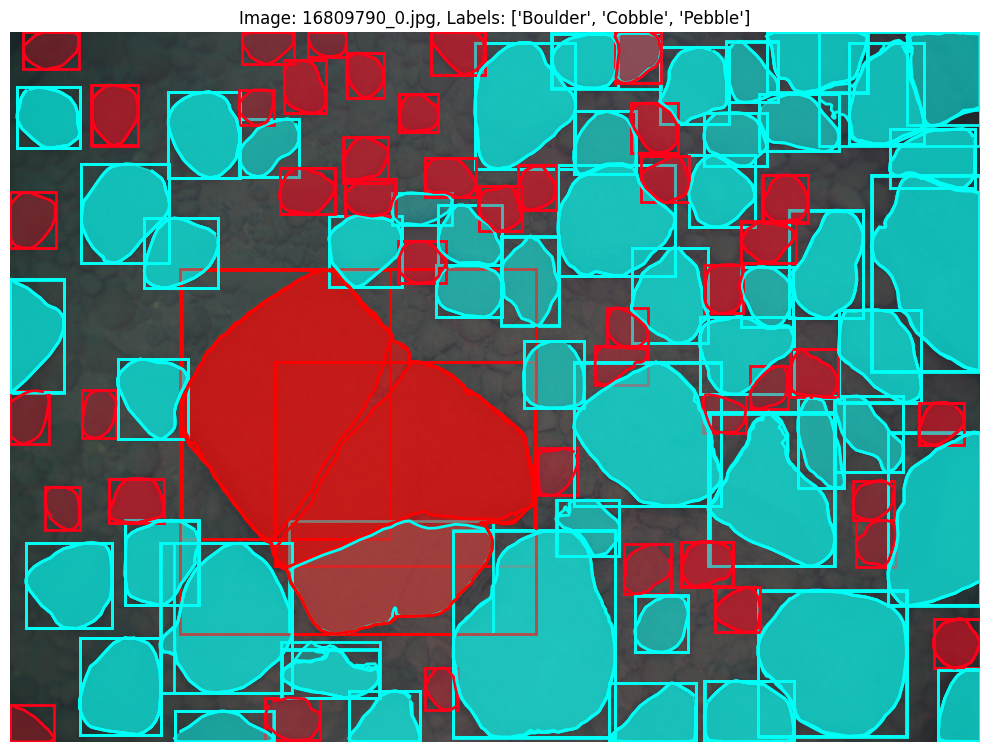

In [5]:
downloader.display_sample()

# Dataset Split

### Ground-Truth 

First, we create a YOLO Dataset (instance segmentation) with the following split:
- Train 70%
- Valid 10%
- Test 20%

### Tiled

Finally, we'll tile the `Ground-Truth`; we can do this by using 
`yolo-tiling`, and simply pointing to the `Ground-Truth` set.


### Ground-Truth

In [6]:
data_dir = "../Data/RockFinder"

# Create a YOLO Dataset using the Ground-Truth data.
# Read in the dataframe from the downloaded data
df = pd.read_csv(f"{data_dir}/Ground-Truth/data.csv")

# Labels are not important for training, fill any NaNs with a placeholder
df = df.fillna({'label': 'Unlabeled'})

# Change the type of 'polygon' from a lists of lists of strings, to floats
# Alternatively, just read the data as a JSON, convert to pandas
df['polygon'] = df['polygon'].apply(eval)
df['polygon'] = df['polygon'].apply(lambda x: np.array(x, dtype=np.float32))

df.sample(3)

,media,frame,image_name,image_path,image_width,image_height,x,y,width,height,polygon,label
5810,14768415,601,14768415_601.jpg,e:\tator-tools\Data\RockFinder\Ground-Truth\im...,NaN,NaN,0.904167,0.506481,0.089063,0.206481,"[[0.9578125, 0.50648147], [0.95416665, 0.50648...",Cobble
11609,16809519,0,16809519_0.jpg,e:\tator-tools\Data\RockFinder\Ground-Truth\im...,NaN,NaN,0.090820,0.350667,0.058838,0.093000,"[[0.11987305, 0.35066667], [0.10913086, 0.352]...",Cobble
6146,14768410,7323,14768410_7323.jpg,e:\tator-tools\Data\RockFinder\Ground-Truth\im...,NaN,NaN,0.435937,0.222222,0.041667,0.044444,"[[0.4359375, 0.24074075], [0.4359375, 0.251851...",Cobble


In [7]:
# Set parameters
output_dir = f"{data_dir}/Ground-Truth"
dataset_name = "YOLO_Dataset_Great-Lakes"

train_ratio = 0.7
test_ratio = 0.2

task = 'segment' # 'detect' or 'segment'

In [8]:
# Create and process dataset
dataset = YOLODataset(
    data=df,
    output_dir=output_dir,
    dataset_name=dataset_name,
    train_ratio=train_ratio,
    test_ratio=test_ratio,
    task=task,
    format_class_names=True, 
)

In [9]:
# Process the dataset
dataset.process_dataset(move_images=False)  # Makes a copy of the images instead of moving them

Processing YOLO dataset with 14981 annotations...
Dataset split: 192 train, 28 valid, 55 test images


Writing segmentation labels:   0%|          | 0/275 [00:00<?, ?it/s]

Copying images:   0%|          | 0/275 [00:00<?, ?it/s]

Dataset created at e:\tator-tools\Data\RockFinder\Ground-Truth\YOLO_Dataset_Great-Lakes
Classes: ['Boulder', 'Cobble', 'FallenWood', 'FineSediment', 'FineWood', 'Pebble', 'PebbleBed', 'Pebblebed', 'Pebbles', 'Unknown', 'Unlabeled', 'WoodyDebris']


Rendering Examples:   0%|          | 0/10 [00:00<?, ?it/s]

Rendered 10 examples to e:\tator-tools\Data\RockFinder\Ground-Truth\YOLO_Dataset_Great-Lakes\examples


In [ ]:
dataset.dataset_dir

### Ground-Truth Tiled Dataset (1920 x 1080, 35% overlap)

In [10]:
config = TileConfig(
    # Size of each tile (width, height). Can be:
    # - Single integer for square tiles: slice_wh=640
    # - Tuple for rectangular tiles: slice_wh=(640, 480)
    slice_wh=(1920, 1080),

    # Overlap between adjacent tiles. Can be:
    # - Single float (0-1) for uniform overlap percentage: overlap_wh=0.1
    # - Tuple of floats for different overlap in each dimension: overlap_wh=(0.1, 0.1)
    # - Single integer for pixel overlap: overlap_wh=64
    # - Tuple of integers for different pixel overlaps: overlap_wh=(64, 48)
    overlap_wh=(0.35, 0.35),

    # Input image file extension to process
    input_ext=".jpg",

    # Output image file extension to save (default: same as input_ext)
    output_ext=None,

    # Type of YOLO annotations to process:
    # - "object_detection": Standard YOLO format (class, x, y, width, height)
    # - "instance_segmentation": YOLO segmentation format (class, x1, y1, x2, y2, ...)
    annotation_type="instance_segmentation",

    # Include negative samples (tiles without any instances)
    include_negative_samples=True
)

src = f"{data_dir}/Ground-Truth/YOLO_Dataset_Great-Lakes"              
dst = f"{data_dir}/Ground-Truth/YOLO_Dataset_Great-Lakes-Tiled"     

tiler = YoloTiler(
    source=src,
    target=dst,
    config=config,
    num_viz_samples=10,                      # Number of samples to visualize
    show_processing_status=False,            # Show the progress of the tiling process
)

In [11]:
tiler.run()

Polygon with insufficient coordinates in 16808991_0_0_1404_1920_1080.jpg
Polygon with insufficient coordinates in 16808991_0_1248_1404_1920_1080.jpg


# Manually Add Negative Samples

In [ ]:
### ---> Do this manually < --- ###

# Train Models

### Benchmark (YOLOv8m on Ground-Truth)

In [ ]:
root = f"{data_dir}/Ground-Truth/YOLO_Dataset_Ground-Truth"

# Initialize the trainer with the required parameters
trainer = ModelTrainer(
    training_data=f"{root}/data.yaml",
    weights="yolov8m-seg.pt",
    output_dir=f"{root}",
    name="results",
    task="segment",
    epochs=100,
    patience=30,
    half=True,
    imgsz=640,
    single_cls=True,
    plots=True,
    batch=0.5,
)

# Train the model
trainer.train_model()

# Evaluate on the model (if test data is available)
trainer.evaluate_model()

### Benchmark (YOLOv8m on Ground-Truth Tiled)

In [ ]:
root = f"{data_dir}/Ground-Truth/YOLO_Dataset_Ground-Truth-Tiled"

# Initialize the trainer with the required parameters
trainer = ModelTrainer(
    training_data=f"{root}/data.yaml",
    weights="yolov8m-seg.pt",
    output_dir=f"{root}",
    name="results",
    task="segment",
    epochs=100,
    patience=30,
    half=True,
    imgsz=640,
    single_cls=True,
    plots=True,
    batch=0.5,
)

# Train the model
trainer.train_model()

# Evaluate on the model (if test data is available)
trainer.evaluate_model()

### Evaluate All models on the Original Ground-Truth

In [ ]:
root = f"{data_dir}/Ground-Truth/YOLO_Dataset_Ground-Truth"
weights = f"{root}/results/weights/best.pt"

# Initialize the trainer with the required parameters
trainer = ModelTrainer(
    training_data=f"{root}/data.yaml",
    weights=weights,
    output_dir=f"{root}/results/ground_truth_test/",
    name="results",
    task="segment",
    epochs=100,
    patience=10,
    half=True,
    imgsz=640,
    single_cls=True,
    plots=True,
    batch=0.5,
)

# Evaluate on the model (if test data is available)
trainer.evaluate_model()

In [ ]:
root = f"{data_dir}/Ground-Truth/YOLO_Dataset_Ground-Truth"
weights = f"{root}-Tiled/results/weights/best.pt"

# Initialize the trainer with the required parameters
trainer = ModelTrainer(
    training_data=f"{root}/data.yaml",
    weights=weights,
    output_dir=f"{root}-Tiled/results/ground_truth_test/",
    name="results",
    task="segment",
    epochs=100,
    patience=10,
    half=True,
    imgsz=640,
    single_cls=True,
    plots=True,
    batch=0.5,
)

# Evaluate on the model (if test data is available)
trainer.evaluate_model()

In [ ]:
all         55       2830      0.673      0.607      0.663      0.549      0.668      0.602      0.646      0.459


In [ ]:
all         55       2830      0.741      0.541      0.646      0.525      0.735      0.537       0.63      0.443


# Great Lakes Model

In [12]:
root = f"{data_dir}/Ground-Truth/YOLO_Dataset_Great-Lakes-Tiled"

# Initialize the trainer with the required parameters
trainer = ModelTrainer(
    training_data=f"{root}/data.yaml",
    weights="rtdetr-l.pt",
    output_dir=f"{root}/results",
    name="rtdetr-l",
    task="detect",
    epochs=100,
    patience=30,
    half=True,
    imgsz=640,
    single_cls=True,
    plots=True,
    batch=0.5,
)

# Train the model
trainer.train_model()

# Evaluate on the model (if test data is available)
trainer.evaluate_model()

New https://pypi.org/project/ultralytics/8.3.105 available  Update with 'pip install -U ultralytics'
Ultralytics 8.3.101  Python-3.10.16 torch-2.6.0+cu118 CUDA:0 (Tesla T4, 16384MiB)
engine\trainer: task=detect, mode=train, model=rtdetr-l.pt, data=../Data/RockFinder/Ground-Truth/YOLO_Dataset_Great-Lakes-Tiled/data.yaml, epochs=100, time=None, patience=30, batch=0.5, imgsz=640, save=True, save_period=10, cache=False, device=0, workers=8, project=../Data/RockFinder/Ground-Truth/YOLO_Dataset_Great-Lakes-Tiled/results, name=rtdetr-l, exist_ok=False, pretrained=True, optimizer=auto, verbose=True, seed=0, deterministic=True, single_cls=True, rect=False, cos_lr=False, close_mosaic=10, resume=False, amp=True, fraction=1.0, profile=False, freeze=None, multi_scale=False, overlap_mask=True, mask_ratio=4, dropout=0.0, val=True, split=val, save_json=False, save_hybrid=False, conf=None, iou=0.7, max_det=300, half=True, dnn=False, plots=True, source=None, vid_stride=1, stream_buffer=False, visualize=

RuntimeError: Dataset '../Data/RockFinder/Ground-Truth/YOLO_Dataset_Great-Lakes-Tiled/data.yaml' error  
Dataset '../Data/RockFinder/Ground-Truth/YOLO_Dataset_Great-Lakes-Tiled/data.yaml' images not found , missing path 'E:\tator-tools\Data\RockFinder\Ground-Truth\Data\RockFinder\Ground-Truth\YOLO_Dataset_Great-Lakes-Tiled\valid\images'
Note dataset download directory is 'C:\Users\jordan.pierce\datasets'. You can update this in 'C:\Users\jordan.pierce\AppData\Roaming\Ultralytics\settings.json'

### Visualize On Video


In [ ]:
video_path = "E:\\tator-tools\\Data\\Raw_Videos\\GL2301_VID_20230725T145731Z_D015_DROPCAM_HIGH_converted.mp4"

root = f"{data_dir}/Ground-Truth/YOLO_Dataset_Ground-Truth-Tiled"
weights = f"{root}/results/weights/best.pt"

output_dir = f"{data_dir}/Ground-Truth/YOLO_Dataset_Ground-Truth-Tiled/results/ground_truth_test"


In [ ]:
from tator_tools.inference_video import VideoInferencer

inferencer = VideoInferencer(
    weights_path=weights,
    model_type='yolo',
    video_path=video_path,
    output_dir=output_dir,
    conf=0.3,
    iou=0.7,
    start_at=0,
    end_at=-1,
    segment=False,
    track=False,
    sahi=False,
    show=False,
)
inferencer.inference()

# AutoDistill YOLO Dataset

Using AutoDistill w/ OmDetTurbo + MobileSAM, create another YOLO Dataset (instance segmentation) on the original 
images (then later merged with the negative samples).

AutoDistill is used in CoralNet-Toolbox using the following parameters:
- OmDetTurbo
- MobileSAM (to convert bounding boxes to masks)
- Ontology:
    - rock -> Boulder
- conf = 0.03
- iou = 0.25
- area_threshold = (0.00, 0.6)

In [ ]:
# Set parameters
api_token = os.getenv("TATOR_TOKEN")
project_id = 155

# Search string comes from Tator's Data Metadata Export utility
search_string = "eyJtZXRob2QiOiJBTkQiLCJvcGVyYXRpb25zIjpbeyJhdHRyaWJ1dGUiOiIkdmVyc2lvbiIsIm9wZXJhdGlvbiI6ImVxIiwiaW52ZXJzZSI6ZmFsc2UsInZhbHVlIjo4Njl9LHsibWV0aG9kIjoiT1IiLCJvcGVyYXRpb25zIjpbeyJhdHRyaWJ1dGUiOiIkdHlwZSIsIm9wZXJhdGlvbiI6ImVxIiwiaW52ZXJzZSI6ZmFsc2UsInZhbHVlIjo0NjB9LHsiYXR0cmlidXRlIjoiJHR5cGUiLCJvcGVyYXRpb24iOiJlcSIsImludmVyc2UiOmZhbHNlLCJ2YWx1ZSI6NTUzfV19XX0="

# Demo for downloading labeled data
frac = 1.0

dataset_name = "AutoDistill"
output_dir = "../Data/RockFinder"

In [ ]:
# Create a downloader for the labeled data
downloader = QueryDownloader(api_token,
                             project_id=project_id,
                             search_string=search_string,
                             frac=frac,
                             output_dir=output_dir,
                             dataset_name=dataset_name,
                             label_field=None,
                             download_width=1920)

In [ ]:
downloader.download_data()

In [ ]:
### ---> Run AutoDistill in CoralNet-Toolbox, save as YOLODataset <--- ###

In [ ]:
### ---> Combine YOLODataset with Negative samples <--- ###

### Compare AutoDistill Labels with Ground-Truth Labels

In [ ]:
# Ground-truth dataset
ground_truth_path = f"{data_dir}/Ground-Truth/YOLO_Dataset_Ground-Truth"

# Take in the ground-truth dataset
ground_truth_ds = sv.DetectionDataset.from_yolo(
    images_directory_path=f"{ground_truth_path}/test/images",
    annotations_directory_path=f"{ground_truth_path}/test/labels",
    data_yaml_path=f"{ground_truth_path}/data.yaml",
)

# AutoDistill dataset
autodistill_path = f"{data_dir}/AutoDistill/YOLO_Dataset_AutoDistill"

# Take in the autodistill dataset
autodistill_ds_train = sv.DetectionDataset.from_yolo(
    images_directory_path=f"{autodistill_path}/train/images",
    annotations_directory_path=f"{autodistill_path}/train/labels",
    data_yaml_path=f"{autodistill_path}/data.yaml",
)

autodistill_ds_valid = sv.DetectionDataset.from_yolo(
    images_directory_path=f"{autodistill_path}/valid/images",
    annotations_directory_path=f"{autodistill_path}/valid/labels",
    data_yaml_path=f"{autodistill_path}/data.yaml",
)

autodistill_ds_test = sv.DetectionDataset.from_yolo(
    images_directory_path=f"{autodistill_path}/test/images",
    annotations_directory_path=f"{autodistill_path}/test/labels",
    data_yaml_path=f"{autodistill_path}/data.yaml",
)

# Merge the auto-distill dataset
autodistill_ds_all = sv.DetectionDataset.merge([autodistill_ds_train, autodistill_ds_valid, autodistill_ds_test])

In [ ]:
# Find the images in the ground-truth test set in the autodistill dataset
image_paths = []

for path, _, annotations in ground_truth_ds:
    image_paths.append(os.path.basename(path))
    
    
images = []
annotations = {}

for path, image, annotation in autodistill_ds_all:
    if os.path.basename(path) in image_paths:
        images.append(path)
        annotations[path] = annotation

In [ ]:
# Create a new dataset
autodistill_ds = sv.DetectionDataset(classes=autodistill_ds_all.classes, 
                                     images=images,
                                     annotations=annotations)

In [ ]:
len(ground_truth_ds), len(autodistill_ds)

In [ ]:
prediction_value

In [ ]:
from supervision.metrics import MeanAveragePrecision
from supervision.metrics import MeanAverageRecall

from supervision.metrics import MetricTarget

map_metric = MeanAverageRecall(MetricTarget.BOXES)

prediction_root = "../Data/RockFinder/AutoDistill/YOLO_Dataset_AutoDistill"

targets = []
predictions = []

for target_path, target_value in ground_truth_ds.annotations.items():
    
    # Target basename
    target_basename = os.path.basename(target_path)
    
    for prediction_path, prediction_value in autodistill_ds.annotations.items():
        if os.path.basename(prediction_path) == target_basename:
            print(f"Target: {target_path}", f"Prediction: {prediction_path}")
            break
        
    targets.append(target_value)
    predictions.append(prediction_value)

In [ ]:
map_metric.update(predictions, targets)


In [ ]:
map_metric.compute()

### Train Model

In [ ]:
root = f"{data_dir}/AutoDistill/YOLO_Dataset_AutoDistill"

# Initialize the trainer with the required parameters
trainer = ModelTrainer(
    training_data=f"{root}/data.yaml",
    weights="yolov8m-seg.pt",
    output_dir=f"{root}",
    name="results",
    task="segment",
    epochs=100,
    patience=30,
    half=True,
    imgsz=640,
    single_cls=True,
    plots=True,
    batch=0.5,
)

# Train the model
trainer.train_model()

# Evaluate on the model (if test data is available)
trainer.evaluate_model()

### Evaluate on Ground-Truth Test set

In [ ]:
gt_root = f"E:/tator-tools/Data/RockFinder/Ground-Truth/YOLO_Dataset_Ground-Truth"

weights = f"{root}/results/weights/best.pt"

# Initialize the trainer with the required parameters
trainer = ModelTrainer(
    training_data=f"{gt_root}/data.yaml",
    weights=weights,
    output_dir=f"{root}/results/ground_truth_test/",
    name="results",
    task="segment",
    epochs=100,
    patience=10,
    half=True,
    imgsz=640,
    single_cls=True,
    plots=True,
    batch=0.5,
)

# Evaluate on the model (if test data is available)
trainer.evaluate_model()